## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually 

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from dotenv import load_dotenv

In [3]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

## Load env variables

In [4]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Load data

In [5]:
data_df = pd.read_csv(os.path.join(DATA_DIR, 'data_with_features.csv'))
data_df.shape

(60840, 26)

In [6]:
data_df.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'BAMLH0A0HYM2',
       'CPIAUCSL', 'DFF', 'ICSA', 'PPIACO', 'REAINTRATREARAT10Y', 'T10Y2Y',
       'USSTHPI', 'VIXCLS', 'month_of_year', 'day_of_week', 'friday',
       'month_sin', 'month_cos', 'macd', 'macd_signal', 'macd_hist', 'rsi_30',
       'cci_30'],
      dtype='object')

## Validations

In [51]:
# get data attributes
nrows = data_df.shape[0]
n_per_tic = data_df.index.nunique()
ntics = data_df['tic'].nunique()
tic_list = data_df['tic'].unique()

In [53]:
# check if rows are equally distributed between stock tickers
assert all(nrows / ntics == data_df['tic'].value_counts())
assert all(n_per_tic == data_df['tic'].value_counts())

In [26]:
# check if every ticker has the same dates
dates = data_df.query(f"tic == '{tic_list[0]}'")['date'].values
for tic in tic_list[1:]:
    dates2 = data_df.query(f"tic == '{tic}'")['date'].values
    assert all(dates == dates2)

In [35]:
# check if low <= open <= high, low <= close <= high
threshold = 1e7
a = abs(data_df['low'] - data_df['open']) < threshold
b = abs(data_df['open'] <= data_df['high']) < threshold
c = abs(data_df['low'] <= data_df['close']) < threshold
d = abs(data_df['close'] <= data_df['high']) < threshold
assert all(a)
assert all(b)
assert all(c)
assert all(d)

In [40]:
# check if dates follow format %Y-%m-%d
dt_index = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df = data_df.set_index(dt_index)

## Analysis config

In [ ]:
## ----- CONFIG ----- ##
date_split = '2018-01-01'

In [57]:
split_query = data_df.index < date_split
train_n = data_df.index[split_query].nunique()
test_n = data_df.index[~split_query].nunique()
print(f'training: {train_n} ({round(100 * train_n / n_per_tic, 2)}%)',
      f'testing: {test_n} ({round(100 * test_n / n_per_tic, 2)}%)',
      sep='\n')

training: 4767 (70.52%)
testing: 1993 (29.48%)


## Analysis - prices

Visually inspect trends

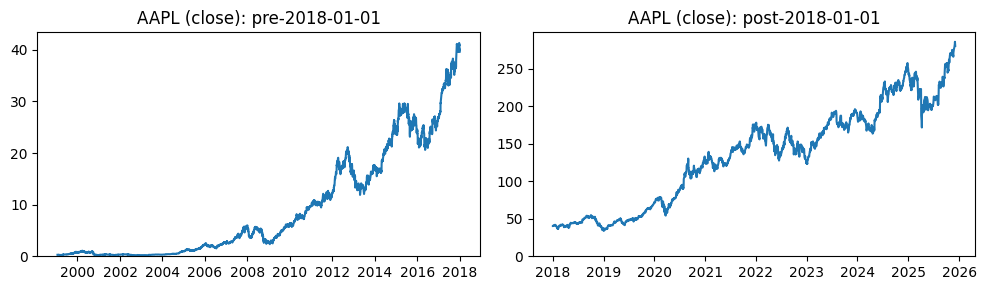

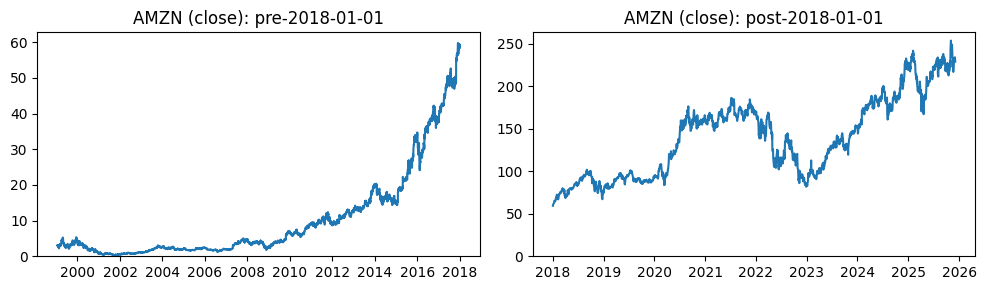

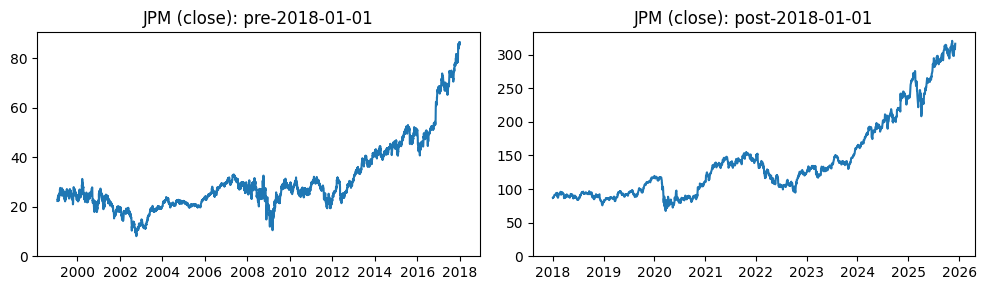

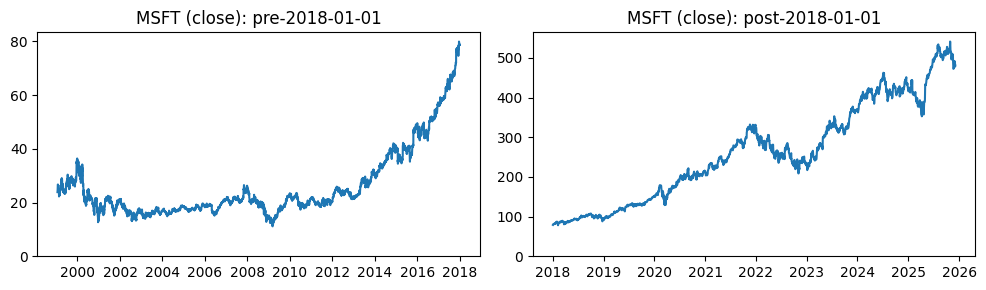

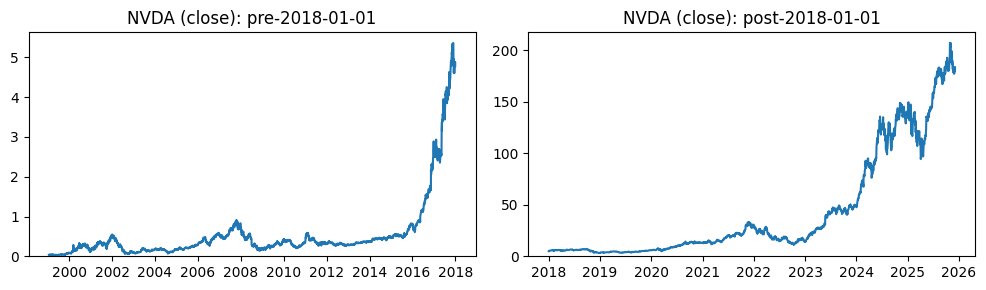

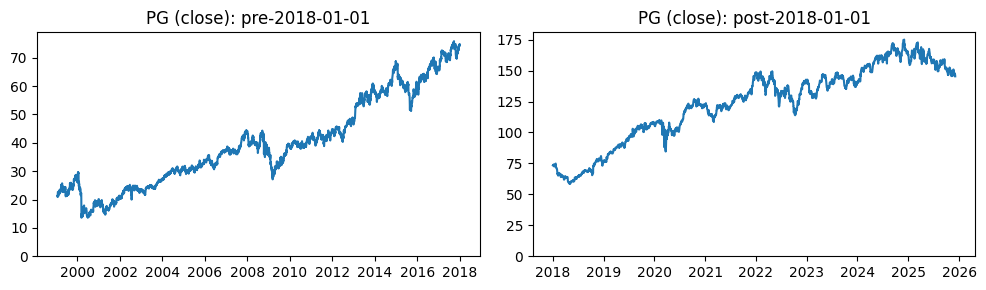

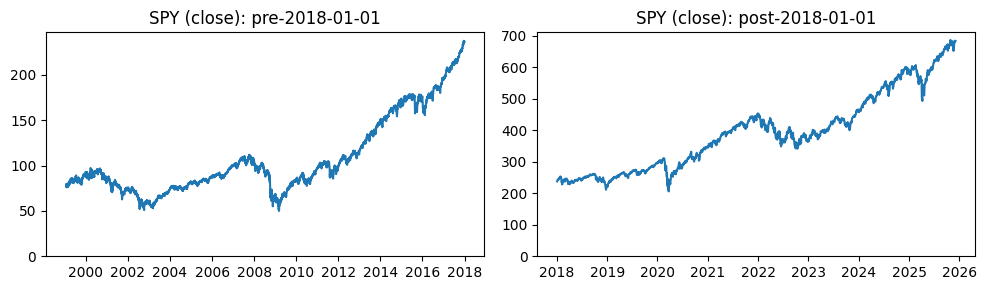

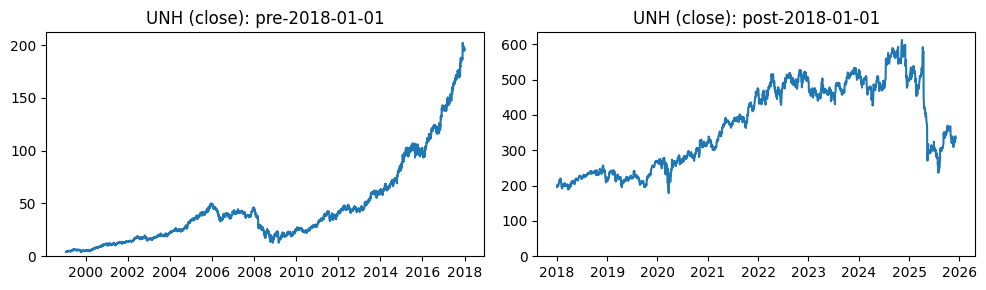

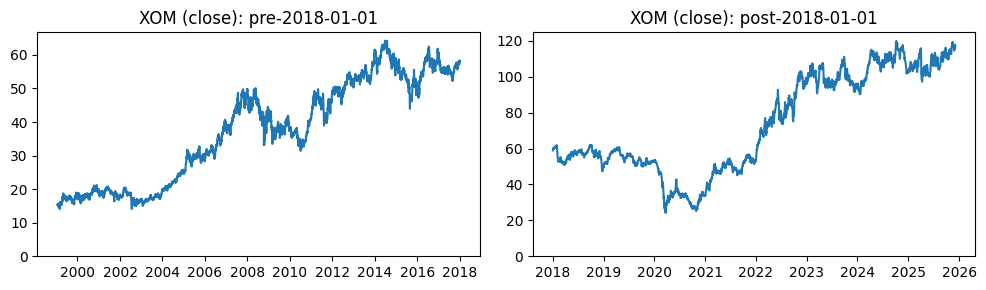

In [58]:
price = 'close'

for tic in tic_list:
    sub_df = data_df.query(f"tic == '{tic}'")

    fig, (ax1, ax2) = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
    ax1.set_title(f'{tic} ({price}): pre-{date_split}')
    ax1.plot(sub_df.query(f"date < '{date_split}'")[price])
    ax1.set_ylim(0)

    ax2.set_title(f'{tic} ({price}): post-{date_split}')
    ax2.plot(sub_df.query(f"date >= '{date_split}'")[price])
    ax2.set_ylim(0)

    plt.tight_layout()

## Analysis - features

In [94]:
## ----- CONFIG ----- ##
STOCK_FEATURES = [
    'macd', 
    'macd_signal', 
    'macd_hist', 
    'rsi_30',
    'cci_30'
]

ECONOMY_FEATURES = [
    'BAMLH0A0HYM2',
    'CPIAUCSL',
    'DFF', 
    'ICSA', 
    'PPIACO', 
    'REAINTRATREARAT10Y', 
    'T10Y2Y',
    'USSTHPI', 
    'VIXCLS',
    'friday',
    'month_sin', 'month_cos'
]

In [95]:
FEATURE_COLS = STOCK_FEATURES + ECONOMY_FEATURES

### Visualize economy features

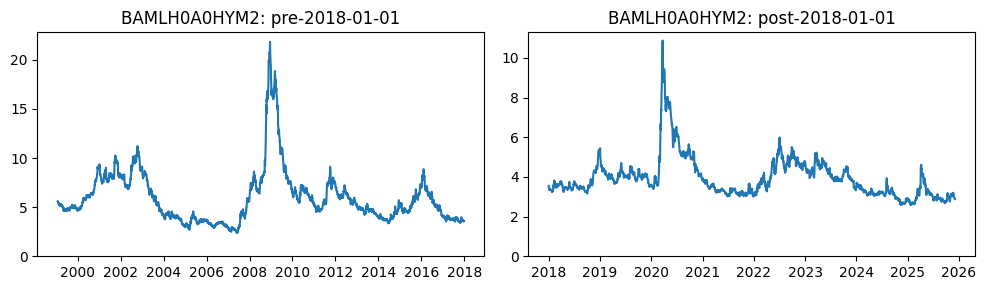

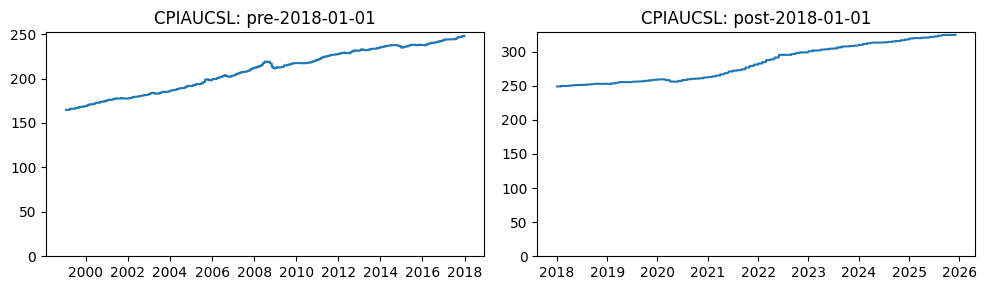

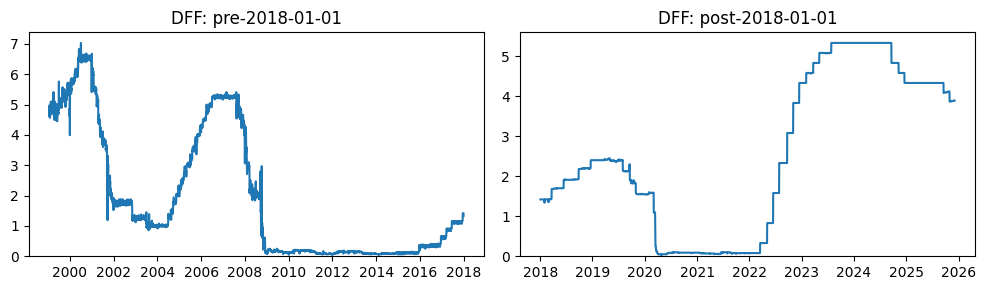

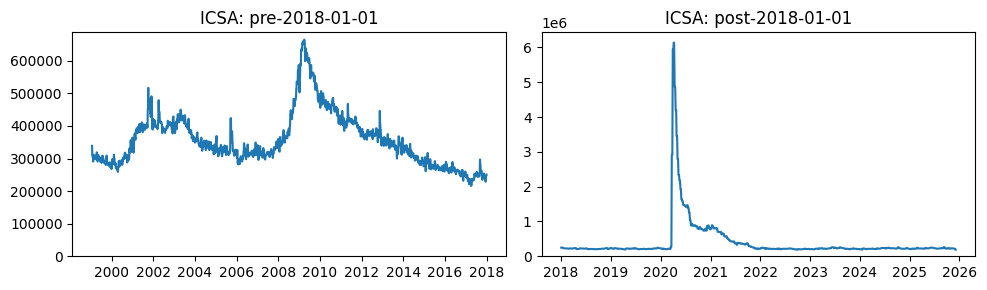

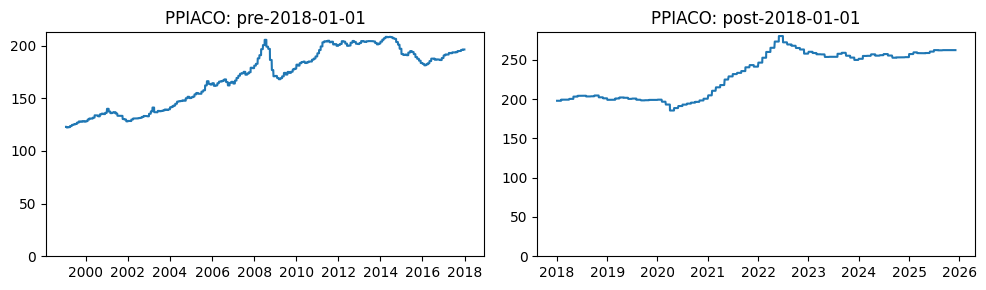

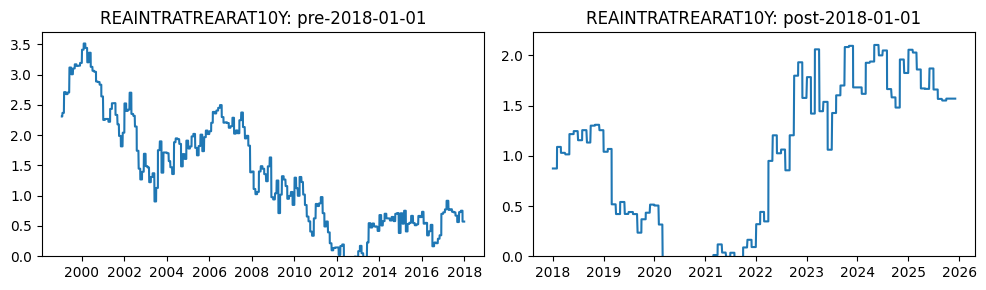

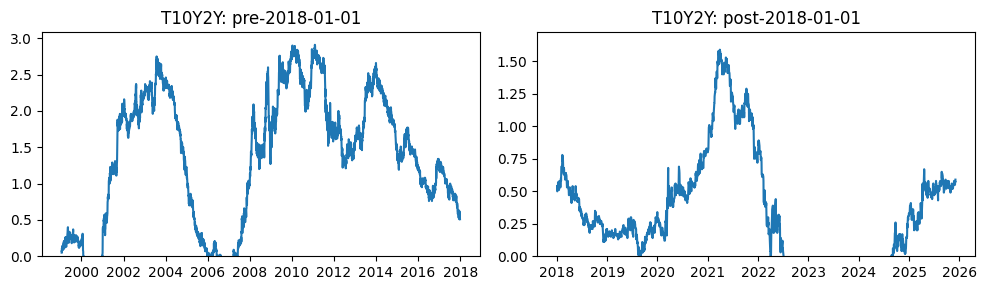

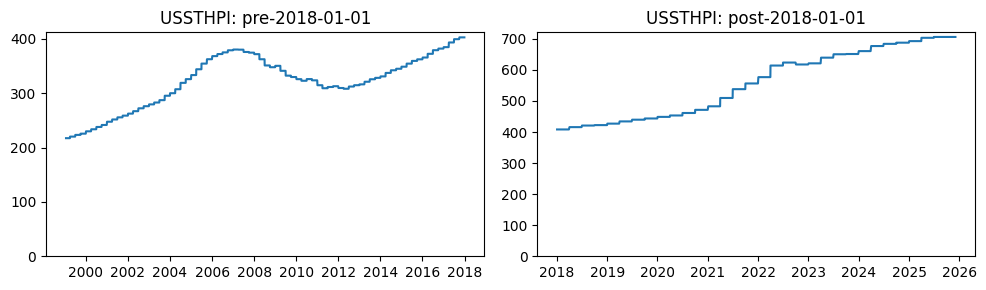

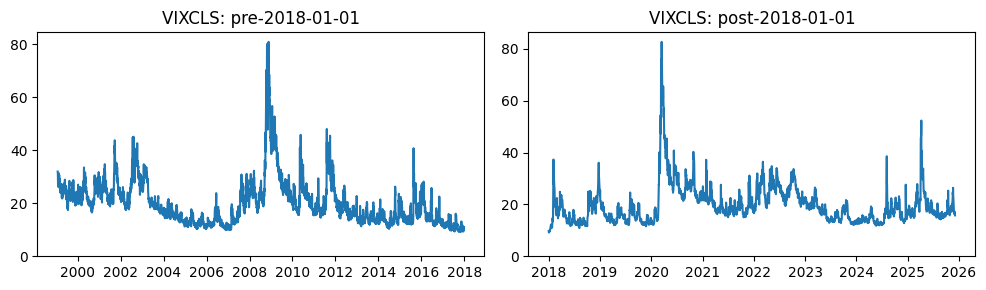

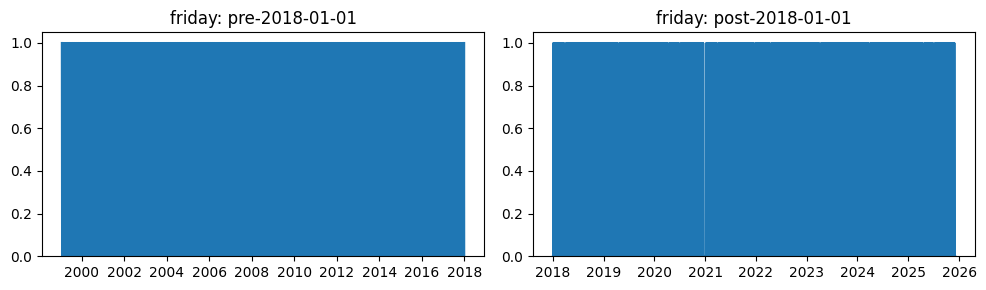

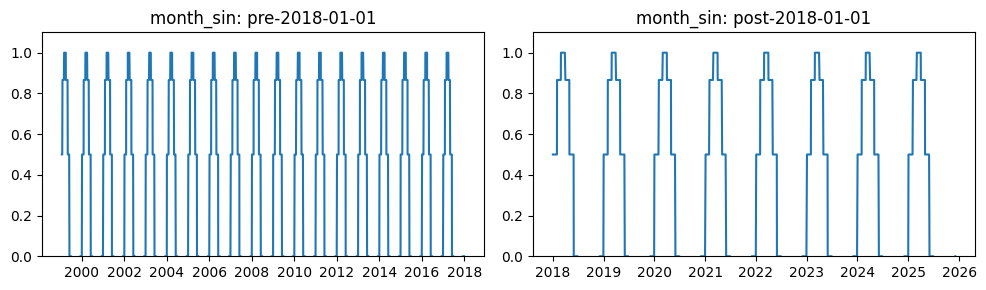

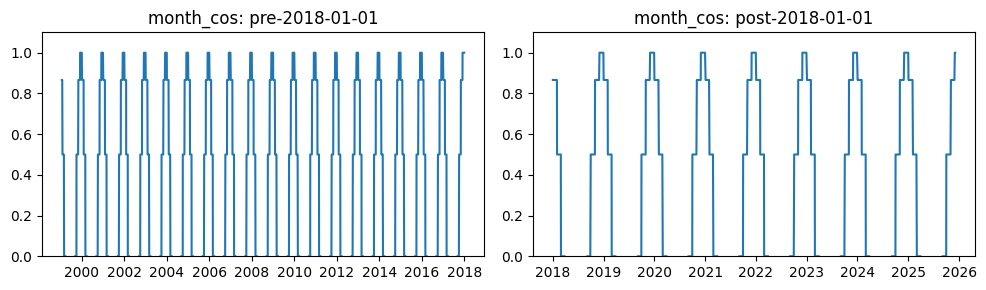

In [96]:
# use data for one tic (since economic features are shared)
sub_df = data_df.query(f"tic == '{tic_list[0]}'")[ECONOMY_FEATURES]

for feat in ECONOMY_FEATURES:
    fig, (ax1, ax2) = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
    ax1.set_title(f'{feat}: pre-{date_split}')
    ax1.plot(sub_df.query(f"date < '{date_split}'")[feat])
    ax1.set_ylim(0)

    ax2.set_title(f'{feat}: post-{date_split}')
    ax2.plot(sub_df.query(f"date >= '{date_split}'")[feat])
    ax2.set_ylim(0)

    plt.tight_layout()

### Feature correlation

In [89]:
# correlation amongst features
corr_df = data_df[FEATURE_COLS].corr()

# get pair-wise structure
pairwise_corr = (
    corr_df.stack()
        .reset_index()
        .rename(columns={'level_0': 'var1',
                         'level_1': 'var2',
                         0: 'corr'})
)

# get unique pairs
pairwise_corr = pairwise_corr[pairwise_corr['var1'] < pairwise_corr['var2']]

# get absolute value of correlation
pairwise_corr['abs_corr'] = abs(pairwise_corr['corr'])

# see distribution
pairwise_corr[['abs_corr']].describe(percentiles=[0.8, 0.9, 0.95]).T

,count,mean,std,min,50%,80%,90%,95%,max
abs_corr,136.0,0.152083,0.219409,0.000046,0.060444,0.25523,0.407003,0.743236,0.962961


In [ ]:
# get highly correlated pairs
pairwise_corr[pairwise_corr['abs_corr'] >= 0.75].sort_values('corr', ascending=False)

,var1,var2,corr,abs_corr
21,CPIAUCSL,PPIACO,0.962961,0.962961
217,macd,macd_signal,0.948832,0.948832
24,CPIAUCSL,USSTHPI,0.938537,0.938537
75,PPIACO,USSTHPI,0.883326,0.883326
39,DFF,REAINTRATREARAT10Y,0.818047,0.818047
287,cci_30,rsi_30,0.810179,0.810179
8,BAMLH0A0HYM2,VIXCLS,0.759734,0.759734


In [ ]:
## ----- CONFIG ----- ##
exclude_cols = [
    'PPIACO', 
    'USSTHPI', 
    'macd_signal', 
    'rsi_30',
    'REAINTRATREARAT10Y', 
    'BAMLH0A0HYM2'
]

In [93]:
SELECTED_FEATURE_COLS = FEATURE_COLS.copy()

for col in exclude_cols:
    SELECTED_FEATURE_COLS.remove(col)

SELECTED_FEATURE_COLS  

['CPIAUCSL',
 'DFF',
 'ICSA',
 'T10Y2Y',
 'VIXCLS',
 'friday',
 'month_sin',
 'month_cos',
 'macd',
 'macd_hist',
 'cci_30']